In [860]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
import h5py
sys.path.append('../')
import analysis_utils as utils
utils.load_plotting_setting()

from astropy.time import Time, TimeDelta
from astropy.coordinates import EarthLocation

In [861]:
datasets_0 = [
            '20241202_8e-8mbar_long',
            '20241204_2e-8mbar_8e_aftercal_long',
            '20241205_2e-8mbar_0e_aftercal_long',
            '20241206_1e-8mbar_0e_aftercal_long',
            '20241207_1e-8mbar_1e_aftercal_long',
            '20241208_1e-8mbar_1e_aftercal_long',
            '20241210_1e-8mbar_8e_alignment1_long',
            '20241210_1e-8mbar_8e_alignment2_long_withdrive',
            '20241210_1e-8mbar_8e_alignment2_long_nodrive',
            '20241211_1e-8mbar_8e_alignment2_long_nodrive',
            '20241212_1e-8mbar_8e_alignment2_long_nodrive',
            '20241213_1e-8mbar_0e_alignment2_long',
            '20241214_1e-8mbar_0e_alignment2_long',
            '20241215_9e-9mbar_0e_alignment2_long',
            '20241216_5e-8mbar_0e_alignment2_long',
            '20241217_6e-8mbar_0e_alignment3_long',
            ]

datasets_1 = ['20250104_4e-8mbar_alignment0_long',
            '20250105_2e-8mbar_alignment0_long',
            '20250106_2e-8mbar_8e_alignment0_long',
            '20250107_1e-8mbar_8e_alignment0_long',
            '20250108_1e-8mbar_8e_alignment0_long',
            '20250109_1e-8mbar_8e_alignment1_long',
            '20250110_1e-8mbar_8e_alignment1_long',
            '20250111_1e-8mbar_8e_alignment1_long',
            '20250112_9e-9mbar_8e_alignment1_long',
            '20250113_5e-8mbar_8e_alignment1_long',
            '20250114_1e-8mbar_1e_alignment1_long',
            '20250115_8e-9mbar_0e_alignment1_long',
            '20250116_8e-9mbar_0e_alignment1_long_wrong_lo',
            '20250117_8e-9mbar_0e_alignment1_long',
            '20250118_8e-9mbar_1e_alignment1_long',
            '20250120_8e-9mbar_1e_alignment1_long_wbackscat',
            '20250121_8e-9mbar_1e_alignment1_long',
            '20250122_8e-9mbar_1e_alignment1_long',
            '20250123_7e-9mbar_1e_alignment1_long',
            '20250124_7e-9mbar_1e_alignment1_long',
            '20250125_7e-9mbar_1e_alignment1_long'    
        ]
datasets_2 = ['20241222_5e-8mbar_10e_alignment0_long']
datasets_3 = ['20241227_6e-8mbar_alignment0_long']

In [ ]:
def get_local_hour(utc_offset, t_utc):
    t_locals = t_utc + TimeDelta(utc_offset * 3600, format='sec')

    t_local_hours = np.empty(t_locals.size)
    for i, t_local in enumerate(t_locals):
        t_local_hours[i] = t_local.datetime.hour + t_local.datetime.minute/60 + t_local.datetime.second/3600

    return t_local_hours

def group_into_days(hours):
    idx_day = np.where(np.diff(hours)<0)[0]

    hours_day = []
    for i, idx_end in enumerate(idx_day):
        if i == 0:
            idx_start = 0
        else:
            idx_start = idx_day[i-1]
        hours_day.append(hours[idx_start+1:idx_end+1])

    # Add the final day
    hours_day.append(hours[idx_end+1:])

    return hours_day

In [862]:
def read_summed_hists(datasets):
    time_per_search = 50e-6 # s
    out_dir = r'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data/for_background'

    bc = None
    hists, livetimes = [], []
    for dataset in datasets:
        outfile_name = f'{dataset}_summed_histograms.hdf5'
        _file = h5py.File(os.path.join(out_dir, outfile_name), 'r')
        
        if bc is None:
            bc = _file['summed_histograms'].attrs['bc']
        hh_det_noise = _file['summed_histograms']['hh_det_noise_sum'][:]
        hh_det_noise_chi2 = _file['summed_histograms']['hh_det_noise_chi2_sum'][:]

        hists.append(hh_det_noise_chi2)
        livetimes.append(np.sum(hh_det_noise) * time_per_search)

        _file.close()
        
    return bc, livetimes, hists

In [863]:
bc_0, livetimes_0, hists_20241202 = read_summed_hists(datasets_0)
bc_1, livetimes_1, hists_20250103 = read_summed_hists(datasets_1)
bc_2, livetimes_2, hists_20241221 = read_summed_hists(datasets_2)
bc_3, livetimes_3, hists_20241226 = read_summed_hists(datasets_3)


/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_6272/1019904869.py:15: RuntimeWarning: divide by zero encountered in log10
  ax0.plot(bc_0, np.log10(hists_20250103[20-i]/livetimes_1[20-i]), z[20-i], zdir='y', color=colors[20-i])
/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_6272/1019904869.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_6272/1019904869.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()
/Users/yuhan/anaconda3/envs/nanospheres/lib/python3.12/site-packages/mpl_toolkits/mplot3d/proj3d.py:177: RuntimeWarning: invalid value encountered in divide
  txs, tys, tzs = vecw[0]/w, vecw[1]/w, vecw[2]/w
/Users/yuhan/anaconda3/envs/nanospheres/lib/python3.12/site-packages/mpl_toolkits/mplot3d/proj3d.py:1

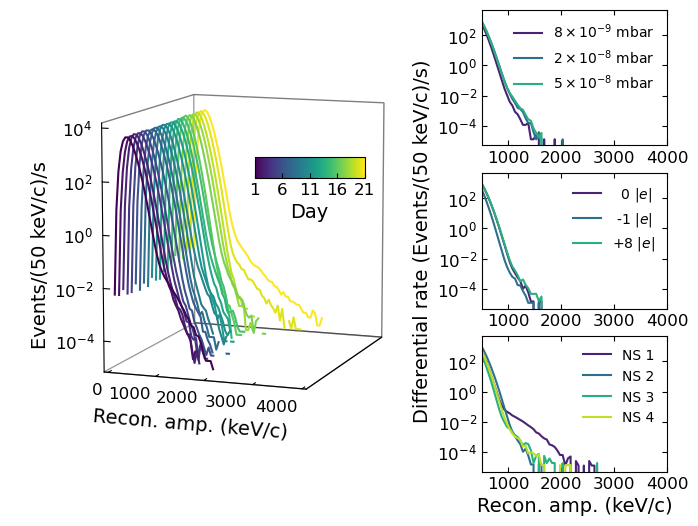

In [864]:
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3D
from matplotlib.ticker import MultipleLocator
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

fig = plt.figure(figsize=(11, 6))
ax0 = fig.add_subplot(1, 1, 1, projection='3d')

cmap = plt.colormaps.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, 21))

z = np.arange(0, 21, 1)
for i in range(len(hists_20250103)):
    ax0.plot(bc_0, np.log10(hists_20250103[20-i]/livetimes_1[20-i]), z[20-i], zdir='y', color=colors[20-i])

ax0.set_yticks([])

# Hide grid and background pane fill
ax0.grid(False)
ax0.xaxis.pane.set_facecolor((1.0, 1.0, 1.0, 0.0))
ax0.yaxis.pane.set_facecolor((1.0, 1.0, 1.0, 0.0))
ax0.zaxis.pane.set_facecolor((1.0, 1.0, 1.0, 0.0))

# Show the pane edges clearly
ax0.xaxis.pane.set_edgecolor('black')
ax0.yaxis.pane.set_edgecolor('black')
ax0.zaxis.pane.set_edgecolor('black')

# Adjusting the ticks and ticklabels
[t.set_va('center') for t in ax0.get_xticklabels()]
[t.set_ha('right') for t in ax0.get_xticklabels()]
[t.set_va('center') for t in ax0.get_zticklabels()]
[t.set_ha('right') for t in ax0.get_zticklabels()]

ax0.xaxis._axinfo['tick']['inward_factor'] = 0
ax0.xaxis._axinfo['tick']['outward_factor'] = 0.4
ax0.zaxis._axinfo['tick']['inward_factor'] = 0
ax0.zaxis._axinfo['tick']['outward_factor'] = 0.4

ax0.set_zticks([-4, -2, 0, 2, 4])
ax0.set_zticklabels(['$10^{-4}$', '$10^{-2}$', '$10^{0}$', '$10^{2}$', '$10^{4}$'])

ax0.xaxis.set_major_locator(MultipleLocator(1000))
ax0.zaxis.set_major_locator(MultipleLocator(2))
ax0.xaxis.set_tick_params(pad=2)
ax0.zaxis.set_tick_params(pad=-2.5)

# Tricks to move z axis to the left
tmp_planes = ax0.zaxis._PLANES 
ax0.zaxis._PLANES = ( tmp_planes[2], tmp_planes[3], 
                     tmp_planes[0], tmp_planes[1], 
                     tmp_planes[4], tmp_planes[5])

ax0.view_init(elev=10, azim=-70)
ax0.set_xlim(0, 4000)

ax0.set_xlabel('Recon. amp. (keV/c)')
ax0.zaxis.set_rotate_label(False)
ax0.set_zlabel('Events/(50 keV/c)/s', labelpad=15, rotation=90)

# Create a fake mappable for the colorbar
norm = Normalize(vmin=1, vmax=21)  # Adjust based on what your z index represents
sm = ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])  # required for matplotlib to handle the ScalarMappable

cax = fig.add_axes([0.525, 0.6, 0.1, 0.035])
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label('Day')
cbar.set_ticks([1, 6, 11, 16, 21])

ax0.set_box_aspect([0.85, 1, 1], zoom=0.85)

## ================================================
## ================================================

ax1 = plt.subplot(3, 4, 4)
ax2 = plt.subplot(3, 4, 8)
ax3 = plt.subplot(3, 4, 12)

colors = cmap(np.linspace(0.1, 0.9, 4))

idx_plot = [17, 2, 9]
labels_pressure = ['$8 \\times 10^{{-9}}$ mbar', '$2 \\times 10^{{-8}}$ mbar', '$5 \\times 10^{{-8}}$ mbar']
for i, idx in enumerate(idx_plot):
    ax1.plot(bc_0, hists_20250103[idx]/livetimes_1[idx], label=labels_pressure[i], color=colors[i])

idx_plot = [11, 15, 7]
labels_charge = [r'  0 $|e|$', r' -1 $|e|$', r'+8 $|e|$']
for i, idx in enumerate(idx_plot):
    ax2.plot(bc_0, hists_20250103[idx]/livetimes_1[idx], label=labels_charge[i], color=colors[i])

ax3.plot(bc_0, hists_20241202[3]/livetimes_0[3], label='NS 1', color=colors[0])
ax3.plot(bc_0, hists_20250103[11]/livetimes_1[11], label='NS 2', color=colors[1])
ax3.plot(bc_0, hists_20241221[0]/livetimes_2[0], label='NS 3', color=colors[2])
ax3.plot(bc_0, hists_20241226[0]/livetimes_3[0], label='NS 4', color=colors[3])

for a in [ax1, ax2, ax3]:
# for a in [ax0]:
    a.set_yscale('log')
    a.set_xlim(500, 4000)
    a.set_ylim(5e-6, 5e3)

for a in [ax1, ax2, ax3]:
    a.legend(frameon=False, fontsize=10)
    a.xaxis.set_major_locator(MultipleLocator(1000))
    a.yaxis.set_ticks([1e-4, 1e-2, 1e0, 1e2])

ax3.set_xlabel('Recon. amp. (keV/c)', fontsize=14)
ax2.set_ylabel('Differential rate (Events/(50 keV/c)/s)', fontsize=14)

fig.tight_layout()
fig.align_labels()

plt.savefig('../paper_plots/background_characterization.pdf', bbox_inches='tight', dpi=600)

## Daily modulation

In [865]:
latitude_newhaven  = 41.31 # deg
longitude_newhaven = -72.923611 # deg
elevation_newhaven = 18 # m

amp2kev_sphere_20241202 = 5945.245097647231
amp2kev_sphere_20250103 = 5923.2059527417405

In [866]:
file0 = h5py.File(rf'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data/sphere_20241202_unbinned_amps.h5py')
file1 = h5py.File(rf'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data/sphere_20250103_unbinned_amps.h5py')

amps0 = file0['unbinned_amps']['amplitude'][:]
amps1 = file1['unbinned_amps']['amplitude'][:]
time0 = file0['unbinned_amps']['time'][:]
time1 = file1['unbinned_amps']['time'][:]

file0.close()
file1.close()

In [867]:
thr_kev = 1250
location = EarthLocation(lat=latitude_newhaven, lon=longitude_newhaven, height=elevation_newhaven)

t0 = Time(time0, format='unix', scale='utc')
t1 = Time(time1, format='unix', scale='utc')

# Calculate the sidereal time
lst0 = t0[np.abs(amps0)*amp2kev_sphere_20241202 > thr_kev].sidereal_time('apparent', longitude=location.lon)
lst1 = t1[np.abs(amps1)*amp2kev_sphere_20250103 > thr_kev].sidereal_time('apparent', longitude=location.lon)

In [895]:
# Group sidereal times into days
_lst0_hour = lst0.hour
_lst1_hour = lst1.hour

hour_day_sidereal_0 = group_into_days(_lst0_hour)
hour_day_sidereal_1 = group_into_days(_lst1_hour)

# Calculate the local time (UTC-5) during data taking
utc_offset = -5

_t0_local_hours = get_local_hour(utc_offset, t0[np.abs(amps0)*amp2kev_sphere_20241202 > thr_kev])
_t1_local_hours = get_local_hour(utc_offset, t1[np.abs(amps1)*amp2kev_sphere_20250103 > thr_kev])

hour_day_solar_0 = group_into_days(_t0_local_hours)
hour_day_solar_1 = group_into_days(_t1_local_hours)

In [ ]:
# Read in the effective livetime (# of windows) for each day
# after livetime selection
npz_livetime = np.load('livetime_windows_day.npz')

livetime_sidereal_0 = npz_livetime['sidereal_0']
livetime_sidereal_1 = npz_livetime['sidereal_1']
livetime_solar_0 = npz_livetime['solar_0']
livetime_solar_1 = npz_livetime['solar_0']

npz_livetime.close()

In [899]:
def bin_events_day(hour_day, bins):
    ret = []
    for hours in hour_day:
        _hist, _ = np.histogram(hours, bins=bins)
        ret.append(_hist)

    return np.array(ret)

# Bin events in individual days into histograms
bins = np.linspace(0, 24, 25)
bc = 0.5 * (bins[1:] + bins[:-1])

hist_day_sidereal_0 = bin_events_day(hour_day_sidereal_0, bins)
hist_day_sidereal_1 = bin_events_day(hour_day_sidereal_1, bins)
hist_day_solar_0 = bin_events_day(hour_day_solar_0, bins)
hist_day_solar_1 = bin_events_day(hour_day_solar_1, bins)

In [944]:
hist_day_solar_0

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  24, 121,  60, 307, 242, 247, 221],
       [189, 224, 202, 178, 207, 215, 223, 257, 215, 210, 148, 395, 303,
        346, 382, 273, 327, 131,  36,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 157,
        121, 191,  65, 176, 124, 233,  48,  80, 179, 197, 113],
       [112, 200, 171, 147, 221, 197, 152, 151,  41,  35,  34, 243, 231,
         89,   0,   0,   0, 120, 156,  61, 136, 146,  60,  65],
       [154, 162, 190,  68,  62, 146, 137, 108, 134, 176,  78,  44, 102,
         24,  73,  78,  87, 140, 145, 140, 122, 116, 173, 125],
       [156, 147, 186, 154, 164, 178, 134, 149, 118,  52,  47, 149,  59,
         44,  43,  68,  74, 175, 181, 115, 239, 237, 244, 131],
       [182, 197, 109, 231, 163, 112, 158, 292, 240, 247, 221,  71,  68,
         68, 159, 224, 261, 182, 261, 116, 153, 139, 150,  72],
       [ 81, 120, 135,  94, 276, 251, 232

In [945]:
livetime_solar_0

array([[     0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,
             0,  72250, 309378, 322615, 328658, 329005, 324145, 320191],
       [324143, 324827, 324509, 325289, 325943, 326014, 325185, 328933,
        330966, 244390, 320046, 337974, 592239, 673583, 674224, 623529,
        566366, 589636, 573020, 279025, 211979, 281115, 337377, 324410],
       [333509, 339678, 339938, 333082, 339155, 340614, 304673, 327381,
        305683, 307634, 319165, 343805, 344475, 176010,      0,      0,
             0, 308509, 332468, 311441, 296150, 324570, 321200, 323626],
       [335537, 328275, 338722, 328720, 317210, 300103, 328721, 319259,
        331053, 343997, 337080, 275643, 312266, 315836, 330165, 329252,
        322637, 303906, 293506, 328092, 317968, 330983, 340319, 345726],
       [345983, 346043, 347439, 346348, 346661, 343866, 341954, 341148,
        335503, 334723, 313567, 340593, 306831, 274635, 3195

In [938]:
hour_day_sidereal_0[2]

array([17.33666508, 17.34451732, 17.3754937 , ..., 23.9981392 ,
       23.9984763 , 23.99891626])

In [919]:
(hist_day_sidereal_0 / livetime_sidereal_0)[2]

/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_6272/2037286497.py:1: RuntimeWarning: divide by zero encountered in divide
  (hist_day_sidereal_0 / livetime_sidereal_0)[2]
/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_6272/2037286497.py:1: RuntimeWarning: invalid value encountered in divide
  (hist_day_sidereal_0 / livetime_sidereal_0)[2]


array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.00041333, 0.00058878,        inf,
              inf,        inf, 0.0004127 , 0.00071673])

In [934]:
i = 2
print(livetime_sidereal_0[i])
print(hist_day_sidereal_0[i])

[277490 216573 275437 335276 327350 328894 340211 337536 333642 336632
 340295 303366 330620 307882 302755 317552 339740 343554 224194      0
      0      0 273807 316714]
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 142
 132 188  59 189 113 227]


array([ 85, 289, 240, 249, 217, 188, 227, 202, 177, 204, 216, 221, 257,
       216, 209, 146, 392, 303, 350, 379, 271, 320, 143,  37])

In [ ]:
# def get_livetime(bins, t_begin, t_end):
#     bin_size = bins[1] - bins[0]
#     ret = np.ones(bins.size - 1) * bin_size

#     for i, b in enumerate(ret):
#         if bins[i+1] < t_begin or bins[i] > t_end:
#             ret[i] = 0
#         if bins[i] < t_begin and bins[i+1] > t_begin:
#             ret[i] = (bins[i+1] - t_begin) / bin_size
#         if bins[i] < t_end and bins[i+1] > t_end:
#             ret[i] = (bins[i+1] - t_end) / bin_size

#     return ret

# def get_estimated_livetimes(bins, hour_day, time, sidereal=True):
#     ret = np.zeros(shape=(len(hour_day), bins.size-1))

#     _tt = Time(np.array([time[0], time[-1]]), format='unix', scale='utc')
#     if sidereal:
#         tt = _tt.sidereal_time('apparent', longitude=location.lon).hour
#     else:
#         tt = get_local_hour(utc_offset, _tt)

#     for i in range(len(hour_day)):
#         t_begin = tt[0] if i == 0 else 0
#         t_end   = tt[-1] if i == (len(hour_day)-1) else 24
#         ret[i] = get_livetime(bins, t_begin, t_end)

    # deadtime = np.zeros(shape=(len(hour_day), bins.size-1))

    # # Identify deadtime from gaps in data
    # idx_large_gap = np.where(np.diff(time) > 6000)[0]
    # for idx_gap in idx_large_gap:
    #     _tt = Time(np.array([time[idx_gap], time[idx_gap+1]]), format='unix', scale='utc')

    #     if sidereal:
    #         tt = _tt.sidereal_time('apparent', longitude=location.lon).hour
    #     else:
    #         tt = get_local_hour(utc_offset, _tt)

    # return ret

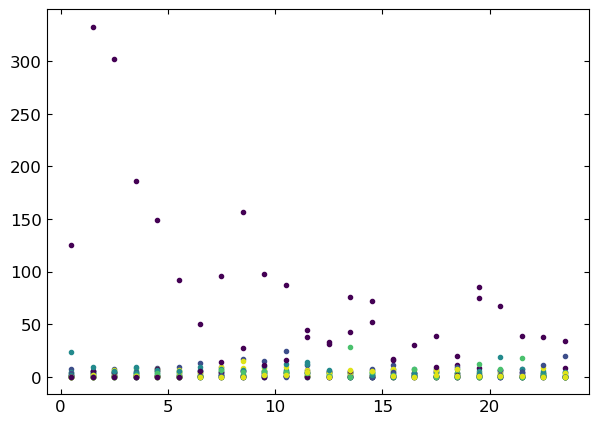

In [855]:
for i in range(len(hists)):
    plt.plot(bc, hists[i], '.')

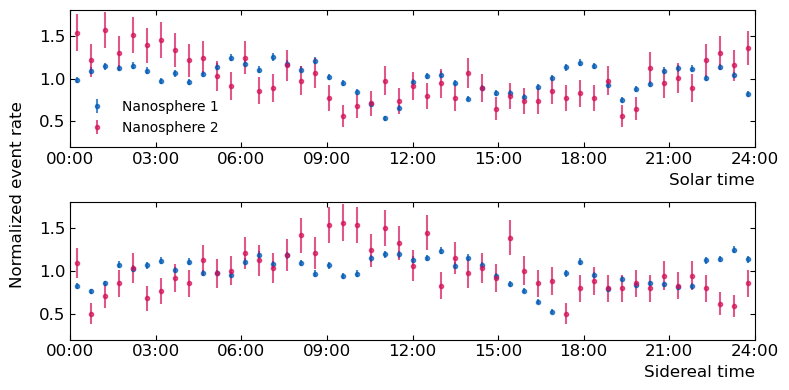

In [ ]:
bins = np.linspace(0, 24, 25)
bc = 0.5 * (bins[1:] + bins[:-1])

hist0_local, be0 = np.histogram(t0_local_hours, bins=bins)
hist1_local, be1 = np.histogram(t1_local_hours, bins=bins)

hist0, be0 = np.histogram(lst0.hour, bins=bins)
hist1, be1 = np.histogram(lst1.hour, bins=bins)

fig, axes = plt.subplots(2, 1, figsize=(8, 4))

axes[0].errorbar(bc, hist0_local/np.mean(hist0_local), yerr=np.sqrt(hist0_local)/np.mean(hist0_local), fmt='.', color='#005AB5', alpha=0.7, label='Nanosphere 1')
axes[0].errorbar(bc, hist1_local/np.mean(hist1_local), yerr=np.sqrt(hist1_local)/np.mean(hist1_local), fmt='.', color='#D41159', alpha=0.7, label='Nanosphere 2')

axes[1].errorbar(bc, hist0/np.mean(hist0), yerr=np.sqrt(hist0)/np.mean(hist0), fmt='.', color='#005AB5', alpha=0.7)
axes[1].errorbar(bc, hist1/np.mean(hist1), yerr=np.sqrt(hist1)/np.mean(hist1), fmt='.', color='#D41159', alpha=0.7)

axes[0].legend(frameon=False, fontsize=10)
fig.supylabel('Normalized event rate', fontsize=12)
axes[0].set_xlabel('Solar time', ha='right', x=1.0, fontsize=12)
axes[1].set_xlabel('Sidereal time', ha='right', x=1.0, fontsize=12)

def float_to_time(x, pos):
    hour = int(x)
    minute = int((x - hour) * 60)
    return f"{hour:02d}:{minute:02d}"

for ax in axes:
    ax.set_xlim(0, 24)
    ax.set_ylim(0.2, 1.8)

    ax.set_xticks(np.arange(0, 27, 3))  # every hour
    ax.xaxis.set_major_formatter(plt.FuncFormatter(float_to_time))

fig.tight_layout()
fig.align_labels()

# plt.savefig('../paper_plots/daily_modulation.pdf', dpi=600)

In [ ]:
location = EarthLocation(lat=latitude_newhaven, lon=longitude_newhaven, height=elevation_newhaven)

def get_hist_days(sphere, datasets, bins, sidereal=True):
    hist_days = []
    hours_tmp = None
    
    for dataset in datasets:
        npz = np.load(fr"E:\livetime_window\{sphere}\{sphere}_{dataset}_livetime_window.npz")
        time_window = npz['livetime_window']
        npz.close()

        tt = Time(time_window, format='unix', scale='utc')
        if sidereal:
            lst = tt.sidereal_time('apparent', longitude=location.lon)
            hours = lst.hour
        else:
            utc_offset = -5
            hours = get_local_hour(utc_offset, tt)

        # Compute histogram until the end of sidereal day
        next_day = False
        _idx_day = np.where(np.diff(hours) < 0)[0]
        if _idx_day.size == 1:
            idx_day = _idx_day[0]
            next_day = True
        else:
            idx_day = hours.size

        _hist, _ = np.histogram(hours[:idx_day+1], bins=bins)

        # If there is left over hours from previous dataset, add them
        # to the histogram
        if hours_tmp is not None:
            _hist_prev, _ = np.histogram(hours_tmp, bins=bins)
            _hist += _hist_prev

        hist_days.append(_hist)

        if next_day:
            hours_tmp = hours[idx_day+1:]
        else:
            hours_tmp = None

    # Add the final bit if there is leftover
    if hours_tmp is not None:
        _hist_leftover, _ = np.histogram(hours_tmp, bins=bins)
        hist_days.append(_hist_leftover)

    return np.asarray(hist_days)
    

In [82]:
bins = np.linspace(0, 24, 25)

hist_days_sidereal_0 = get_hist_days(sphere='sphere_20241202', datasets=datasets_0, bins=bins, sidereal=True)
hist_days_sidereal_1 = get_hist_days(sphere='sphere_20250103', datasets=datasets_1, bins=bins, sidereal=True)

In [83]:
hist_days_solar_0 = get_hist_days(sphere='sphere_20241202', datasets=datasets_0, bins=bins, sidereal=False)
hist_days_solar_1 = get_hist_days(sphere='sphere_20250103', datasets=datasets_1, bins=bins, sidereal=False)

In [84]:
np.savez('livetime_windows_day.npz', sidereal_0=hist_days_sidereal_0, sidereal_1=hist_days_sidereal_1, solar_0=hist_days_solar_0, solar_1=hist_days_solar_1)

In [92]:
hist_days_solar_1

array([[     0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,
             0, 188372, 333302, 336513, 331842, 316575, 310724, 306916],
       [328586, 322953, 297210, 317351, 305072, 314725, 312035, 307518,
        304896, 292276, 321302, 315519, 314118, 310806, 309383, 315724,
        276686, 272739, 254504, 293404, 268452, 317062, 315332, 319383],
       [292151, 325317, 309846, 329156, 290716, 287957, 264066, 310845,
        303489, 191162,  95729, 327304, 333194, 287399, 336779, 335232,
        343124, 289485, 333412, 317523, 323876, 330613, 329928, 319724],
       [325648, 321753, 321134, 330670, 313155, 323454, 323507, 328026,
        308448, 202395, 331286, 330856,  84139, 335181, 331005, 328806,
        330799, 325851, 323982, 323821, 334806, 319900, 313222, 312684],
       [309032, 311775, 315493, 311672, 308048, 307042, 307225, 309421,
        321105, 309476, 308464, 316427, 331637, 185987,  740